## Sentiment Analysis using NLP Pipeline & ML Models
### Dataset
IMDb Movie Reviews Dataset — 50,000 movie reviews labeled as Positive or Negative  
Source: [Kaggle]


### Step 0: Install & Import Libraries

In [12]:
# Install required libraries (run once)
# ── Standard Libraries ──
import re
import string
import warnings
warnings.filterwarnings('ignore')

# ── Data Handling ──
import numpy as np
import pandas as pd

# ── Visualization ──
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

# ── NLP ──
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# ── Feature Engineering ──
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ── Model Building ──
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ── Model Evaluation ──
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report, confusion_matrix)

print("All libraries imported successfully!")

All libraries imported successfully!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



###Step 1: Data Loading & Understanding

In [13]:
#Option A: Load via kagglehub
import kagglehub
path = kagglehub.dataset_download('lakshmi25npathi/imdb-dataset-of-50k-movie-reviews')
df = pd.read_csv(f"{path}/IMDB Dataset.csv")

#Option B: Load from local file
# df = pd.read_csv('IMDB Dataset.csv')

# Option C: Load a sample directly from a public URL
# url = "https://raw.githubusercontent.com/skathirmani/Sentiment_analysis/master/IMDB_Dataset.csv"
# df = pd.read_csv(url)

print(f"Dataset Shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
df.head()

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset Shape : (50000, 2)
Columns       : ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [14]:
# ── Basic Information ──
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total Samples  : {len(df)}")
print(f"Missing Values : {df.isnull().sum().sum()}")
print(f"Duplicates     : {df.duplicated().sum()}")
print()
print("Class Distribution:")
print(df['sentiment'].value_counts())
print()
print("Sample Review (Positive):")
print(df[df['sentiment'] == 'positive']['review'].iloc[0][:300], "...")
print()
print("Sample Review (Negative):")
print(df[df['sentiment'] == 'negative']['review'].iloc[0][:300], "...")

DATASET OVERVIEW
Total Samples  : 50000
Missing Values : 0
Duplicates     : 418

Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample Review (Positive):
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru ...

Sample Review (Negative):
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to ma ...


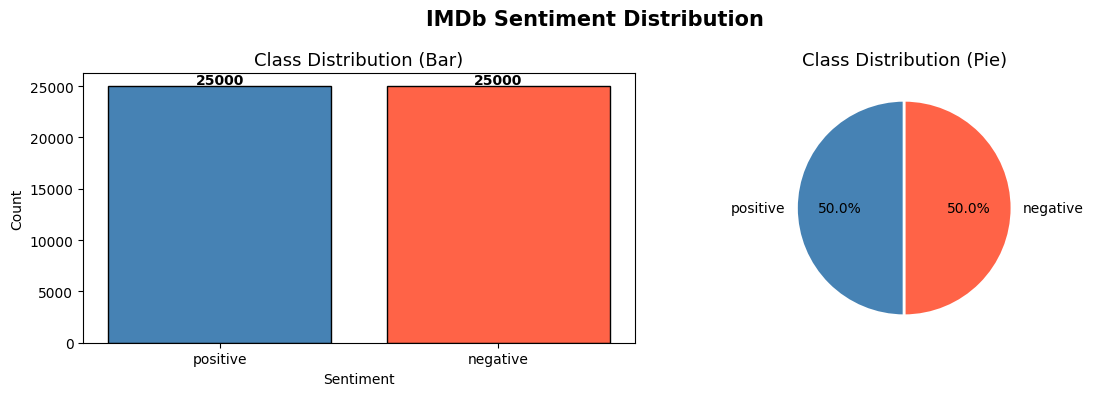

The dataset is perfectly balanced — 25,000 positive and 25,000 negative reviews.


In [15]:
# ── Visualise Class Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['sentiment'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution (Bar)', fontsize=13)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index,
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (Pie)', fontsize=13)

plt.suptitle('IMDb Sentiment Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("The dataset is perfectly balanced — 25,000 positive and 25,000 negative reviews.")

Review Length Statistics:
          review_length                                                       \
                  count    mean     std   min    25%    50%     75%      max   
sentiment                                                                      
negative        25000.0  1294.1   945.9  32.0  706.0  973.0  1567.2   8969.0   
positive        25000.0  1324.8  1031.5  65.0  691.0  968.0  1614.0  13704.0   

          word_count                                                   
               count   mean    std   min    25%    50%    75%     max  
sentiment                                                              
negative     25000.0  229.5  164.9   4.0  128.0  174.0  278.0  1522.0  
positive     25000.0  232.8  177.5  10.0  125.0  172.0  284.0  2470.0  


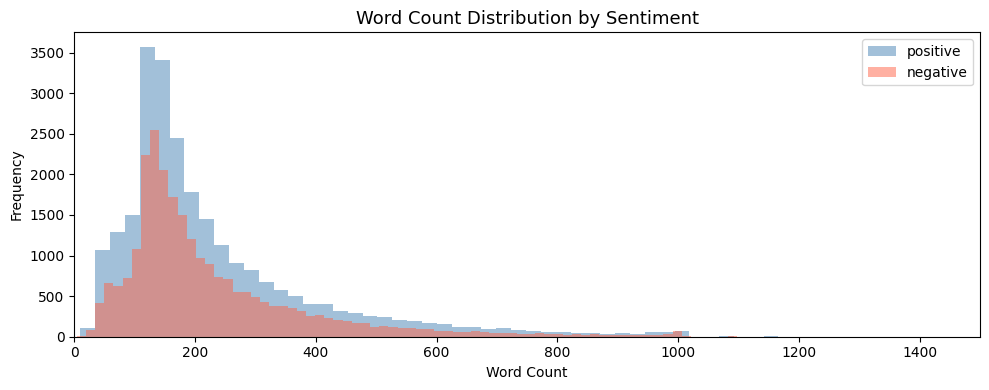

In [16]:
# ── Review Length Analysis ──
df['review_length'] = df['review'].apply(len)
df['word_count']    = df['review'].apply(lambda x: len(x.split()))

print("Review Length Statistics:")
print(df.groupby('sentiment')[['review_length', 'word_count']].describe().round(1))

# Plot word count distribution
fig, ax = plt.subplots(figsize=(10, 4))
for sent, color in [('positive', 'steelblue'), ('negative', 'tomato')]:
    subset = df[df['sentiment'] == sent]['word_count']
    ax.hist(subset, bins=100, alpha=0.5, color=color, label=sent)
ax.set_title('Word Count Distribution by Sentiment', fontsize=13)
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.legend()
ax.set_xlim(0, 1500)
plt.tight_layout()
plt.show()


###Step 2: NLP Preprocessing Pipeline

In [17]:
# Initialise NLP tools
STOP_WORDS  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()
stemmer     = PorterStemmer()

# ── Reusable Preprocessing Functions ──

def remove_html_tags(text: str) -> str:
    """Remove HTML tags (e.g., <br />, <p>, etc.)"""
    clean = re.compile('<.*?>')
    return re.sub(clean, ' ', text)


def remove_urls(text: str) -> str:
    """Remove URLs (http/https/www links)"""
    return re.sub(r'http\S+|www\.\S+', '', text)


def remove_special_characters(text: str) -> str:
    """Remove special chars and digits; keep only alphabets and spaces"""
    return re.sub(r'[^a-z\s]', '', text)


def remove_punctuation(text: str) -> str:
    """Remove all punctuation marks"""
    return text.translate(str.maketrans('', '', string.punctuation))


def to_lowercase(text: str) -> str:
    """Convert all characters to lowercase"""
    return text.lower()


def tokenize(text: str) -> list:
    """Split text into individual word tokens"""
    return word_tokenize(text)


def remove_stopwords(tokens: list) -> list:
    """Remove common stopwords (e.g., 'the', 'is', 'in')"""
    return [t for t in tokens if t not in STOP_WORDS and len(t) > 2]


def lemmatize_tokens(tokens: list) -> list:
    """Reduce each token to its base/dictionary form (e.g., 'running' → 'run')"""
    return [lemmatizer.lemmatize(t) for t in tokens]


def stem_tokens(tokens: list) -> list:
    """Reduce each token to its root stem (more aggressive than lemmatization)"""
    return [stemmer.stem(t) for t in tokens]


def full_preprocess(text: str, use_lemma: bool = True) -> str:
    """
    Full NLP preprocessing pipeline:
      HTML removal → URL removal → Lowercase → Punctuation removal
      → Special char removal → Tokenization → Stopword removal
      → Lemmatization (or Stemming)
    Returns a clean string ready for vectorization.
    """
    text = remove_html_tags(text)
    text = remove_urls(text)
    text = to_lowercase(text)
    text = remove_punctuation(text)
    text = remove_special_characters(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    if use_lemma:
        tokens = lemmatize_tokens(tokens)   # preferred: preserves meaning
    else:
        tokens = stem_tokens(tokens)        # alternative: faster but crude
    return ' '.join(tokens)


print(" Preprocessing functions defined.")

# ── Quick Demo ──
sample = df['review'].iloc[0]
print("\n--- Raw Text (first 200 chars) ---")
print(sample[:200])
print("\n--- Cleaned Text ---")
print(full_preprocess(sample)[:200])

 Preprocessing functions defined.

--- Raw Text (first 200 chars) ---
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

--- Cleaned Text ---
one reviewer mentioned watching episode youll hooked right exactly happened first thing struck brutality unflinching scene violence set right word trust show faint hearted timid show pull punch regard


In [18]:
#  Apply preprocessing to the full dataset
# Use a 10k subset for speed (increase to 50k if running on a powerful machine)

SAMPLE_SIZE = 10000   # change to len(df) for full dataset
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

print(f"Working with {SAMPLE_SIZE} samples...")
df_sample['clean_review'] = df_sample['review'].apply(full_preprocess)

# Encode labels: positive=1, negative=0
df_sample['label'] = df_sample['sentiment'].map({'positive': 1, 'negative': 0})

print(" Preprocessing complete!")
print(f"\nClass Balance after sampling:")
print(df_sample['sentiment'].value_counts())
df_sample[['review', 'clean_review', 'sentiment', 'label']].head(3)

Working with 10000 samples...
 Preprocessing complete!

Class Balance after sampling:
sentiment
positive    5039
negative    4961
Name: count, dtype: int64


,review,clean_review,sentiment,label
0,I really liked this Summerslam due to the look...,really liked summerslam due look arena curtain...,positive,1
1,Not many television shows appeal to quite as m...,many television show appeal quite many differe...,positive,1
2,The film quickly gets to a major chase scene w...,film quickly get major chase scene ever increa...,negative,0


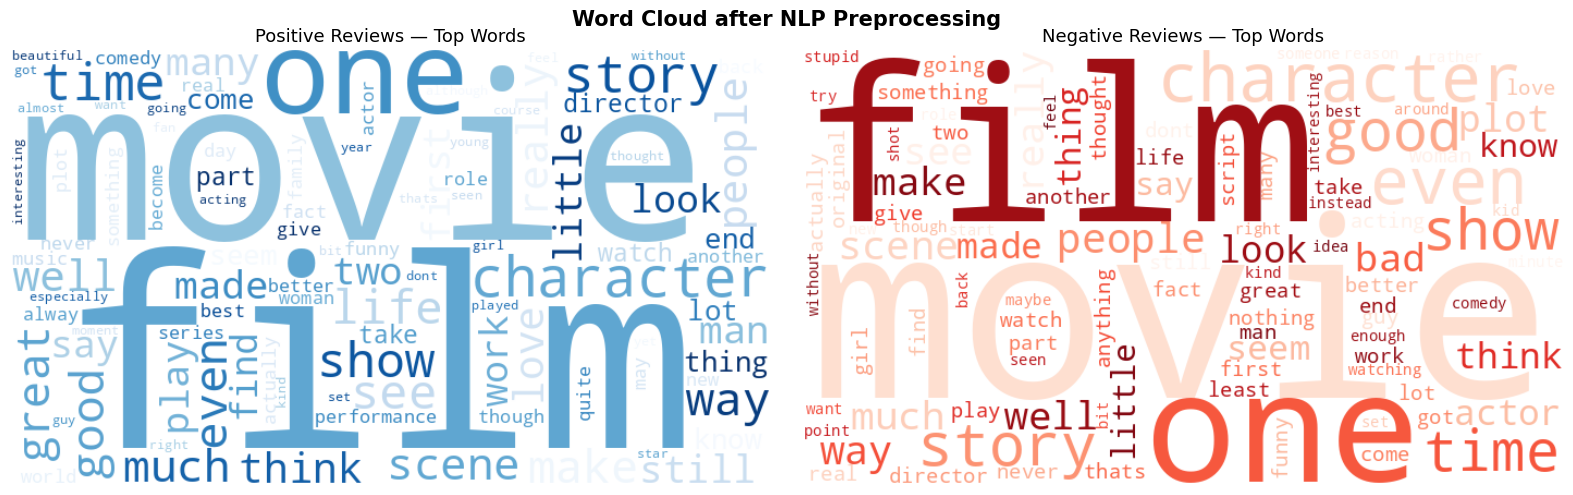

In [19]:
# WordCloud: Top words after preprocessing
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, (sentiment, color_map) in enumerate([('positive', 'Blues'), ('negative', 'Reds')]):
    text_blob = ' '.join(df_sample[df_sample['sentiment'] == sentiment]['clean_review'])
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap=color_map, max_words=100).generate(text_blob)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'{sentiment.capitalize()} Reviews — Top Words', fontsize=13)

plt.suptitle('Word Cloud after NLP Preprocessing', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


###Step 3: Feature Engineering

In [20]:
X = df_sample['clean_review']
y = df_sample['label']

# Train-Test Split (80:20, stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 8000
Testing  samples : 2000


In [21]:
# ── 3A: Bag of Words (BoW) ──
# CountVectorizer converts text into a matrix of token counts
bow_vectorizer = CountVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_bow = bow_vectorizer.fit_transform(X_train)   # fit+transform on train
X_test_bow  = bow_vectorizer.transform(X_test)        # transform only on test

print("BoW Matrix Shape (train):", X_train_bow.shape)
print("BoW Matrix Shape (test) :", X_test_bow.shape)
print("Sample features:", bow_vectorizer.get_feature_names_out()[:10])

BoW Matrix Shape (train): (8000, 10000)
BoW Matrix Shape (test) : (2000, 10000)
Sample features: ['aamir' 'aaron' 'abandon' 'abandoned' 'abbey' 'abbott' 'abbott costello'
 'abc' 'ability' 'able']


In [22]:
# ── 3B: TF-IDF (Term Frequency – Inverse Document Frequency) ──
# TF-IDF down-weights common words and emphasizes discriminative words
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print("TF-IDF Matrix Shape (train):", X_train_tfidf.shape)
print("TF-IDF Matrix Shape (test) :", X_test_tfidf.shape)

TF-IDF Matrix Shape (train): (8000, 10000)
TF-IDF Matrix Shape (test) : (2000, 10000)


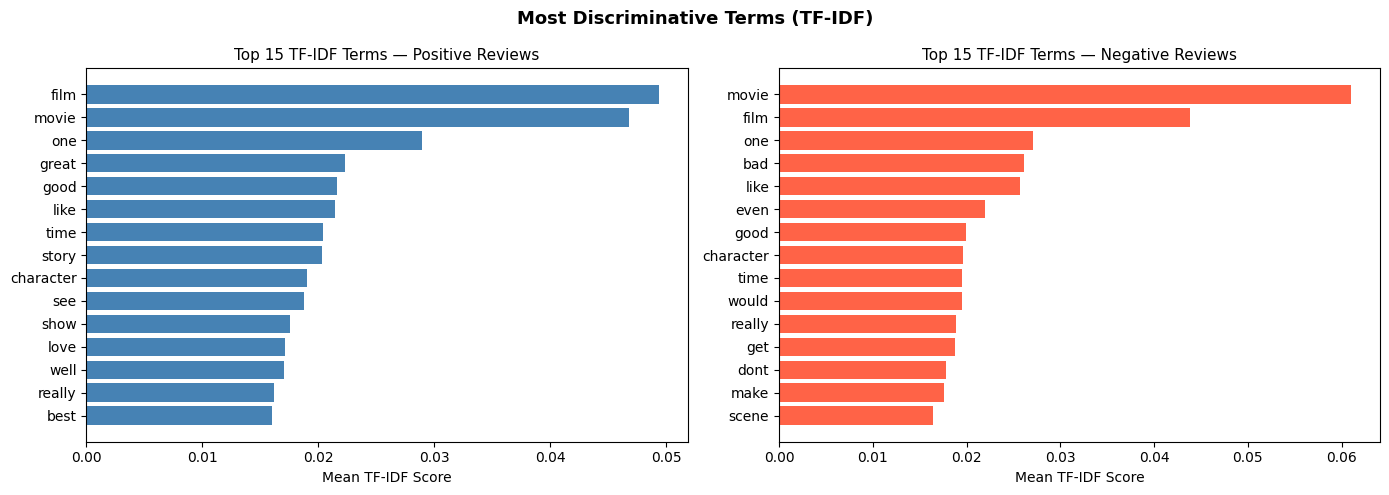

In [23]:
# ── Visualise Top TF-IDF Terms per Class ──
tfidf_df = pd.DataFrame(X_train_tfidf.toarray(),
                        columns=tfidf_vectorizer.get_feature_names_out())
tfidf_df['label'] = y_train.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, (label, title, color) in enumerate([
        (1, 'Positive Reviews', 'steelblue'),
        (0, 'Negative Reviews', 'tomato')]):
    top_terms = (tfidf_df[tfidf_df['label'] == label]
                 .drop('label', axis=1).mean().sort_values(ascending=False).head(15))
    axes[idx].barh(top_terms.index[::-1], top_terms.values[::-1], color=color)
    axes[idx].set_title(f'Top 15 TF-IDF Terms — {title}', fontsize=11)
    axes[idx].set_xlabel('Mean TF-IDF Score')

plt.suptitle('Most Discriminative Terms (TF-IDF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

del tfidf_df   # free memory

---
### Step 4: Model Building & Training

In [24]:
# ── Define Models ──
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes'         : MultinomialNB(alpha=0.5),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=20, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
}

# ── Helper: train & evaluate a single model ──
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, vectorizer_name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'Model'      : name,
        'Vectorizer' : vectorizer_name,
        'Accuracy'   : round(accuracy_score(y_te, y_pred)  * 100, 2),
        'Precision'  : round(precision_score(y_te, y_pred) * 100, 2),
        'Recall'     : round(recall_score(y_te, y_pred)    * 100, 2),
        'F1-Score'   : round(f1_score(y_te, y_pred)        * 100, 2),
        'Predictions': y_pred   # store for confusion matrix
    }

results = []

# ── Train on BoW features ──
print("Training on Bag-of-Words features...")
for name, model in models.items():
    r = evaluate_model(name, model,
                       X_train_bow, X_test_bow, y_train, y_test, 'BoW')
    results.append(r)
    print(f"  ✓ {name:25s} Acc={r['Accuracy']}%  F1={r['F1-Score']}%")

# ── Train on TF-IDF features ──
print("\nTraining on TF-IDF features...")
for name, model in models.items():
    r = evaluate_model(name, model,
                       X_train_tfidf, X_test_tfidf, y_train, y_test, 'TF-IDF')
    results.append(r)
    print(f"  ✓ {name:25s} Acc={r['Accuracy']}%  F1={r['F1-Score']}%")

print("\nAll models trained and evaluated!")

Training on Bag-of-Words features...
  ✓ Logistic Regression       Acc=84.75%  F1=84.95%
  ✓ Naive Bayes               Acc=84.0%  F1=84.1%
  ✓ Decision Tree             Acc=70.95%  F1=73.21%
  ✓ Random Forest             Acc=84.1%  F1=84.07%

Training on TF-IDF features...
  ✓ Logistic Regression       Acc=86.2%  F1=86.61%
  ✓ Naive Bayes               Acc=85.0%  F1=85.29%
  ✓ Decision Tree             Acc=71.35%  F1=73.14%
  ✓ Random Forest             Acc=82.95%  F1=82.91%

All models trained and evaluated!



### Step 5: Model Evaluation

In [25]:
# ── Results Table ──
results_df = pd.DataFrame(results).drop(columns='Predictions')
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("=" * 75)
print("COMPLETE EVALUATION RESULTS")
print("=" * 75)
print(results_df.to_string(index=False))

COMPLETE EVALUATION RESULTS
              Model Vectorizer  Accuracy  Precision  Recall  F1-Score
Logistic Regression     TF-IDF     86.20      84.72   88.59     86.61
        Naive Bayes     TF-IDF     85.00      84.30   86.31     85.29
Logistic Regression        BoW     84.75      84.49   85.42     84.95
        Naive Bayes        BoW     84.00      84.26   83.93     84.10
      Random Forest        BoW     84.10      84.92   83.23     84.07
      Random Forest     TF-IDF     82.95      83.79   82.04     82.91
      Decision Tree        BoW     70.95      68.39   78.77     73.21
      Decision Tree     TF-IDF     71.35      69.33   77.38     73.14


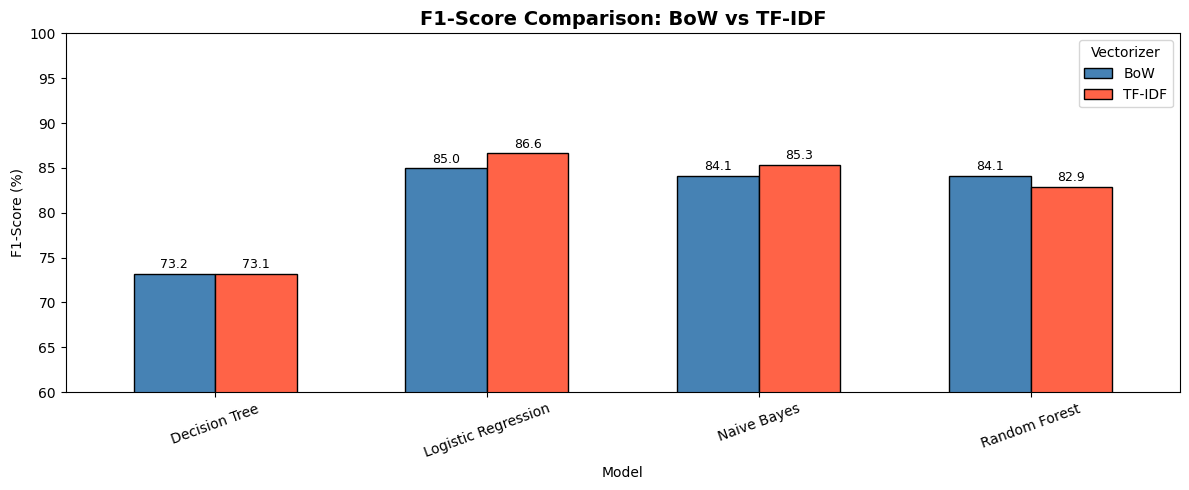

In [26]:
# ── Grouped Bar Chart: F1-Score comparison ──
pivot = results_df.pivot(index='Model', columns='Vectorizer', values='F1-Score')

fig, ax = plt.subplots(figsize=(12, 5))
pivot.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'],
           edgecolor='black', width=0.6)
ax.set_title('F1-Score Comparison: BoW vs TF-IDF', fontsize=14, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('F1-Score (%)')
ax.set_ylim(60, 100)
ax.legend(title='Vectorizer')
ax.tick_params(axis='x', rotation=20)

# Annotate bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=2, fontsize=9)

plt.tight_layout()
plt.show()

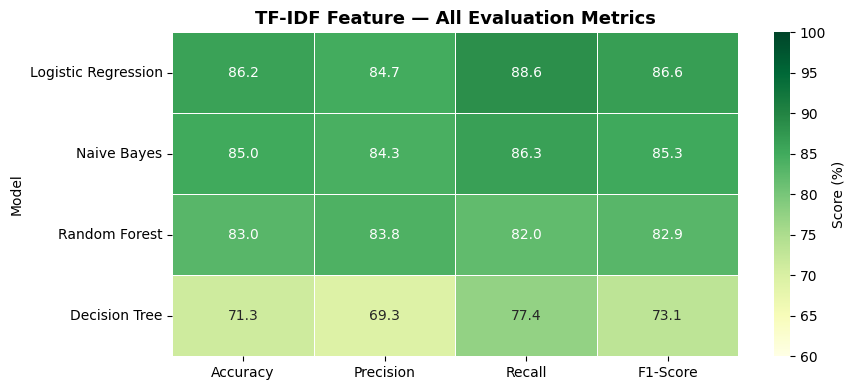

In [27]:
# ── Heatmap: All Metrics (TF-IDF) ──
tfidf_results = results_df[results_df['Vectorizer'] == 'TF-IDF'].set_index('Model')
metrics_df = tfidf_results[['Accuracy', 'Precision', 'Recall', 'F1-Score']]

plt.figure(figsize=(9, 4))
sns.heatmap(metrics_df, annot=True, fmt='.1f', cmap='YlGn',
            linewidths=0.5, cbar_kws={'label': 'Score (%)'},
            vmin=60, vmax=100)
plt.title('TF-IDF Feature — All Evaluation Metrics', fontsize=13, fontweight='bold')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

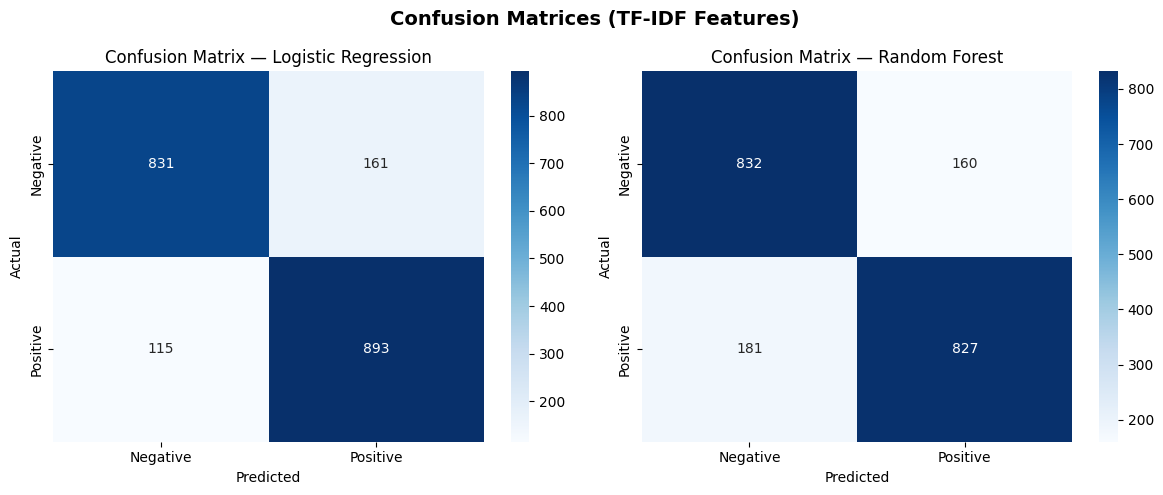

In [28]:
# ── Confusion Matrices for best model (TF-IDF) ──
# Re-train Logistic Regression + Random Forest on TF-IDF and plot confusion matrices
top_models = ['Logistic Regression', 'Random Forest']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name in zip(axes, top_models):
    model = models[name]
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices (TF-IDF Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# ── Detailed Classification Report for Best Model ──
best_model = LogisticRegression(max_iter=1000, random_state=42)
best_model.fit(X_train_tfidf, y_train)
y_pred_best = best_model.predict(X_test_tfidf)

print("=" * 55)
print("Classification Report — Logistic Regression (TF-IDF)")
print("=" * 55)
print(classification_report(y_test, y_pred_best,
                             target_names=['Negative', 'Positive']))

Classification Report — Logistic Regression (TF-IDF)
              precision    recall  f1-score   support

    Negative       0.88      0.84      0.86       992
    Positive       0.85      0.89      0.87      1008

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000




### Step 6: Comparison & Insights

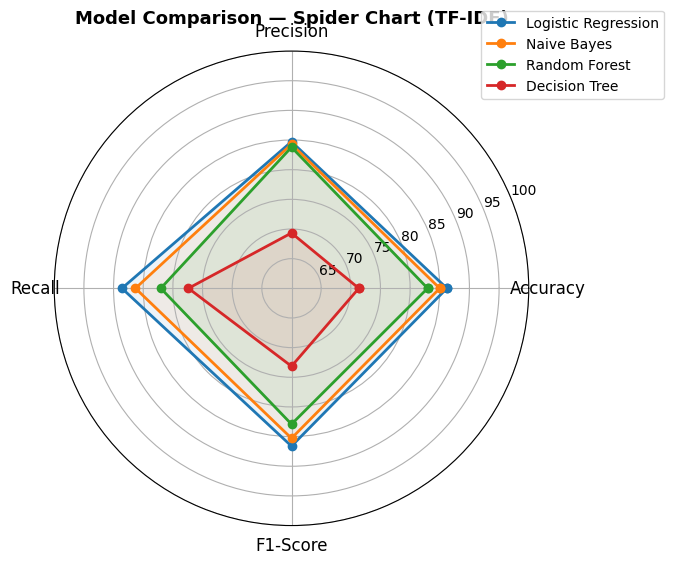

In [30]:
# ── Radar / Spider Chart for TF-IDF models ──
import matplotlib.patches as mpatches
from matplotlib.path import Path
import numpy as np

categories   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
N            = len(categories)
angles       = [n / float(N) * 2 * np.pi for n in range(N)]
angles      += angles[:1]   # close the polygon

tfidf_df2 = results_df[results_df['Vectorizer'] == 'TF-IDF']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})

for i, (_, row) in enumerate(tfidf_df2.iterrows()):
    values = [row[c] for c in categories]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2,
            label=row['Model'], color=colors[i % len(colors)])
    ax.fill(angles, values, alpha=0.08, color=colors[i % len(colors)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(60, 100)
ax.set_title('Model Comparison — Spider Chart (TF-IDF)', size=13,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()